In [74]:
import pandas as pd
from tabulate import tabulate
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [75]:
# Ler o CSV
df = pd.read_csv("Charging_Data_educational.csv")


# Mostrar o DataFrame como tabela
print(
    f"""
    Head Dataset

    {tabulate(
        df.head(10),
        headers="keys",
        tablefmt="grid",
        showindex=False
    )}
    """
)

print(f"""
Tail Dataset

{tabulate(
    df.tail(10),
    headers="keys",
    tablefmt="grid",
    showindex=False
)}
""")


    Head Dataset

    +----------+--------------------+-------------------------------+-----------------+-----------------------+-------------------------+-------------------------+-----------------------+---------------------------+-----------------------+---------------------+---------------------+---------------------+------------------+------------------------+---------------------+------------------------+---------------------+-----------------+-----------------------------+-----------------------------+----------------------------------+-----------------------------+-----------------------------+----------------------------------+------------------------------+------------------------------+-----------------------------------+-----------------------------------------------+--------------------------------------+------------------------------------------------+---------------------------------------+---------------+------------------------------+------------------------------+---

In [76]:
#3.Get all information about the dataframe, such as the number of rows, number of columns, column names and their types.
print("-- info --")
print(df.info())
print("\n")

-- info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441077 entries, 0 to 441076
Data columns (total 47 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   UserID                                        441077 non-null  int64  
 1   Charging Post ID                              441077 non-null  int64  
 2   Location Information                          441077 non-null  object 
 3   District Name                                 441077 non-null  object 
 4   Order creation time                           441077 non-null  object 
 5   Transaction power/kwh                         441077 non-null  float64
 6   Electricity cost/Yuan                         441077 non-null  float64
 7   Service charge/Yuan                           441077 non-null  float64
 8   Transaction Amount/Yuan                       441077 non-null  float64
 9   Actual Payment/Yuan                  

In [77]:
#4. View only the variable names in this dataframe.
print("-- variable names --")
print(df.columns)
print("\n")

-- variable names --
Index(['UserID', 'Charging Post ID', 'Location Information', 'District Name',
       'Order creation time', 'Transaction power/kwh', 'Electricity cost/Yuan',
       'Service charge/Yuan', 'Transaction Amount/Yuan', 'Actual Payment/Yuan',
       'Start Time', 'End Time', 'Payment time', 'Temperature(℃)',
       'Relative Humidity(%)', 'Precipitation(mm)', 'end_cause',
       'electricity_price', 'tariff_period', 'post_previous_sessions_1D',
       'post_previous_abnormal_1D', 'post_previous_abnormal_rate_1D',
       'post_previous_sessions_7D', 'post_previous_abnormal_7D',
       'post_previous_abnormal_rate_7D', 'post_previous_sessions_30D',
       'post_previous_abnormal_30D', 'post_previous_abnormal_rate_30D',
       'post_hours_since_previous_completed_session',
       'post_no_previous_completed_session',
       'post_hours_since_previous_completed_abnormal',
       'post_no_previous_completed_abnormal', 'is_new_user',
       'user_previous_sessions_30D', 'user

In [78]:
#5. What is the size of the data set?

print(f"Shape : {df.shape}")
print(f"Size : {df.size}")
print("\n")

Shape : (441077, 47)
Size : 20730619




In [79]:
#6. Get statistics from the dataframe's numerical columns and frequency tables for categorical variables.
print(f"Describe \n: {df.describe()}")
print("\n")

Describe 
:               UserID  Charging Post ID  Transaction power/kwh  \
count  441077.000000     441077.000000          441077.000000   
mean    13262.864430         48.829583              16.436574   
std     14286.825468         25.045206              13.253881   
min         1.000000          1.000000               0.000000   
25%      2478.000000         26.000000               5.440000   
50%      8819.000000         51.000000              15.150000   
75%     19614.000000         69.000000              24.740000   
max     56117.000000         92.000000             117.740000   

       Electricity cost/Yuan  Service charge/Yuan  Transaction Amount/Yuan  \
count          441077.000000        441077.000000            441077.000000   
mean               12.158460             7.450791                19.609251   
std                10.830214             8.152830                15.958935   
min                 0.000000             0.000000                 0.000000   
25%         

In [80]:
#7.Get values from the dataframe's text columns.
print(f"""Describe \n: {df.select_dtypes(include="object")}""")
print("\n")

Describe 
:        Location Information District Name    Order creation time  \
0             Shopping Mall     Tongxiang  2019-12-31 21:26:58\t   
1         Government Agency       Xiuzhou  2019-12-31 21:50:58\t   
2                    Park B     Tongxiang  2019-12-31 22:19:34\t   
3             Shopping Mall     Tongxiang  2019-12-31 22:37:24\t   
4               Bus Station     Tongxiang  2019-12-31 23:32:28\t   
...                     ...           ...                    ...   
441072    Industrial Park\t     Tongxiang  2021-12-31 23:40:47\t   
441073     Wholesale Market       Xiuzhou  2021-12-31 23:40:24\t   
441074          Bus Station     Tongxiang  2021-12-31 23:46:55\t   
441075   Tourist Attraction         Nanhu  2021-12-31 23:48:11\t   
441076    Industrial Park\t     Tongxiang  2021-12-31 23:54:12\t   

                 Start Time             End Time           Payment time  \
0       2019-12-31 21:27:03  2020-01-01 05:03:53  2020-01-01 05:03:40\t   
1       2019-12-31 21

In [81]:
#8.Check null values from columns dataframe.
print("-- Count number of Nas per column. --")
print(df.isna().sum())
print(f"Initial rows: {len(df)}")
print("\n")


-- Count number of Nas per column. --
UserID                                               0
Charging Post ID                                     0
Location Information                                 0
District Name                                        0
Order creation time                                  0
Transaction power/kwh                                0
Electricity cost/Yuan                                0
Service charge/Yuan                                  0
Transaction Amount/Yuan                              0
Actual Payment/Yuan                                  0
Start Time                                           0
End Time                                             0
Payment time                                         0
Temperature(℃)                                       0
Relative Humidity(%)                                 0
Precipitation(mm)                                    0
end_cause                                            0
electricity_price          

In [82]:
#9. Remove the line with all columns: NaN.
print("-- Remove rows where all columns are NaN --")

df.dropna(how="all", inplace=True)

print(f"Remaining rows: {len(df)}")
print(f"Rows with all NaN: {df.isna().all(axis=1).sum()}")

print("\nMissing values per column:")
print(df.isna().sum())


-- Remove rows where all columns are NaN --
Remaining rows: 441077
Rows with all NaN: 0

Missing values per column:
UserID                                               0
Charging Post ID                                     0
Location Information                                 0
District Name                                        0
Order creation time                                  0
Transaction power/kwh                                0
Electricity cost/Yuan                                0
Service charge/Yuan                                  0
Transaction Amount/Yuan                              0
Actual Payment/Yuan                                  0
Start Time                                           0
End Time                                             0
Payment time                                         0
Temperature(℃)                                       0
Relative Humidity(%)                                 0
Precipitation(mm)                                    0
end_

In [83]:

# 10. Check columns with many null values

print("-- Columns with null values --")

nulls = df.isna().sum()
null_percentage = (df.isna().mean() * 100)

null_summary = pd.DataFrame({
    "Null_Count": nulls,
    "Null_Percentage": null_percentage
})

# Mostrar apenas colunas que têm valores nulos
null_summary = null_summary[null_summary["Null_Count"] > 0]

print(
    tabulate(
        null_summary,
        headers="keys",
        tablefmt="grid"
    )
)


#verificar qual o motivo pelo qual tem valores null e atribuir uma label para cada uma das situações (-1)

-- Columns with null values --
+----------------------------------------------+--------------+-------------------+
|                                              |   Null_Count |   Null_Percentage |
+==============================================+==============+===================+
| post_hours_since_previous_completed_session  |           92 |         0.020858  |
+----------------------------------------------+--------------+-------------------+
| post_hours_since_previous_completed_abnormal |          367 |         0.0832054 |
+----------------------------------------------+--------------+-------------------+
| user_days_since_previous_completed_session   |        56647 |        12.8429    |
+----------------------------------------------+--------------+-------------------+
| user_days_since_previous_completed_abnormal  |       136279 |        30.8969    |
+----------------------------------------------+--------------+-------------------+


### Investigação dos valores em falta nas variáveis históricas

Algumas variáveis históricas apresentam valores em falta (`NaN`). Antes de decidir como tratar estes valores, é necessário perceber **por que razão estão em falta**.

Por exemplo, a variável `user_days_since_previous_completed_session` indica quantos dias passaram desde a sessão anterior concluída pelo utilizador. No entanto, se o utilizador nunca teve uma sessão concluída anteriormente, não existe uma sessão anterior a partir da qual seja possível calcular esse valor. Neste caso, o valor em falta pode ser esperado e não representar um erro nos dados.

O dataset contém também variáveis indicadoras que informam se existe ou não histórico anterior, como `user_no_previous_completed_session`.

Assim, cada variável de tempo histórico é comparada com o respetivo indicador de ausência de histórico. O objetivo é responder à seguinte questão:

**Quando uma variável de tempo histórico está em falta, o indicador correspondente confirma que não existe histórico anterior?**

Se esta relação se verificar para todos os valores em falta, podemos concluir que estes valores têm um significado específico e não resultam de um problema de qualidade dos dados.

In [84]:
# Pair each historical time variable with its corresponding indicator
missing_history_pairs = {
    "post_hours_since_previous_completed_session":
        "post_no_previous_completed_session",

    "post_hours_since_previous_completed_abnormal":
        "post_no_previous_completed_abnormal",

    "user_days_since_previous_completed_session":
        "user_no_previous_completed_session",

    "user_days_since_previous_completed_abnormal":
        "user_no_previous_completed_abnormal"
}

for time_col, flag_col in missing_history_pairs.items():

    print(f"\n--- {time_col} ---")

    print(pd.crosstab(
        df[flag_col],
        df[time_col].isna(),
        rownames=[flag_col],
        colnames=["Time is missing"],
        margins=True
    ))


--- post_hours_since_previous_completed_session ---
Time is missing                      False  True     All
post_no_previous_completed_session                      
0                                   440985     0  440985
1                                        0    92      92
All                                 440985    92  441077

--- post_hours_since_previous_completed_abnormal ---
Time is missing                       False  True     All
post_no_previous_completed_abnormal                      
0                                    440710     0  440710
1                                         0   367     367
All                                  440710   367  441077

--- user_days_since_previous_completed_session ---
Time is missing                      False   True     All
user_no_previous_completed_session                       
0                                   384430      0  384430
1                                        0  56647   56647
All                               

### Tratamento dos valores em falta nas variáveis históricas

A análise anterior mostrou que os valores em falta nas variáveis de tempo histórico ocorrem quando **não existe histórico anterior disponível**.

Por exemplo, quando `user_no_previous_completed_session = 1`, significa que não existe nenhuma sessão anterior concluída para esse utilizador. Por isso, não é possível calcular `user_days_since_previous_completed_session`, o que explica a existência do valor em falta.

Como estes `NaN` representam uma situação com significado e não um erro nos dados, é necessário atribuir-lhes uma representação numérica antes de utilizar estas variáveis na modelação.

Os valores em falta são substituídos por `-1`. Este valor é adequado porque um período de tempo decorrido não pode ser negativo. Assim:

- um valor positivo representa o tempo efetivamente decorrido desde a sessão anterior;
- `-1` representa a ausência de uma sessão anterior e, consequentemente, a impossibilidade de calcular o tempo decorrido.

As variáveis indicadoras `no_previous` são mantidas, uma vez que identificam explicitamente se existe ou não histórico anterior.

In [85]:
history_time_columns = [
    "post_hours_since_previous_completed_session",
    "post_hours_since_previous_completed_abnormal",
    "user_days_since_previous_completed_session",
    "user_days_since_previous_completed_abnormal"
]

df[history_time_columns] = df[history_time_columns].fillna(-1)

### Notas

A análise confirmou que os valores em falta nas quatro variáveis de tempo histórico não resultam de valores desconhecidos ou de erros de qualidade dos dados. Estes valores ocorrem porque **não existe uma sessão anterior concluída ou uma sessão anterior anormal** a partir da qual seja possível calcular o tempo decorrido.

Assim, os valores em falta foram considerados representativos da ausência de histórico, e não como problemas de qualidade dos dados.

Para preparar os dados para a modelação, os valores em falta foram substituídos por `-1`, representando a ausência de histórico anterior. As respetivas variáveis indicadoras `no_previous` foram mantidas para preservar explicitamente esta informação.

In [86]:
#11.Standardize columns names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9]+", "_", regex=True)
    .str.strip("_")
)

print(df.columns)
print("\n")

Index(['userid', 'charging_post_id', 'location_information', 'district_name',
       'order_creation_time', 'transaction_power_kwh', 'electricity_cost_yuan',
       'service_charge_yuan', 'transaction_amount_yuan', 'actual_payment_yuan',
       'start_time', 'end_time', 'payment_time', 'temperature',
       'relative_humidity', 'precipitation_mm', 'end_cause',
       'electricity_price', 'tariff_period', 'post_previous_sessions_1d',
       'post_previous_abnormal_1d', 'post_previous_abnormal_rate_1d',
       'post_previous_sessions_7d', 'post_previous_abnormal_7d',
       'post_previous_abnormal_rate_7d', 'post_previous_sessions_30d',
       'post_previous_abnormal_30d', 'post_previous_abnormal_rate_30d',
       'post_hours_since_previous_completed_session',
       'post_no_previous_completed_session',
       'post_hours_since_previous_completed_abnormal',
       'post_no_previous_completed_abnormal', 'is_new_user',
       'user_previous_sessions_30d', 'user_previous_abnormal_30d',
   

In [87]:
#12.Número de linhas duplicadas
print(f"\nNúmero de linhas duplicadas (antes de remover): {df.duplicated().sum()}")


Número de linhas duplicadas (antes de remover): 0


In [88]:
# Variáveis que não devem assumir valores negativos
non_negative_columns = [
    "transaction_power_kwh",
    "electricity_cost_yuan",
    "service_charge_yuan",
    "transaction_amount_yuan",
    "actual_payment_yuan",
    "precipitation_mm",
    "electricity_price"
]

for col in non_negative_columns:
    negative_count = (df[col] < 0).sum()
    
    print(f"{col}: {negative_count} valores negativos")

transaction_power_kwh: 0 valores negativos
electricity_cost_yuan: 0 valores negativos
service_charge_yuan: 0 valores negativos
transaction_amount_yuan: 0 valores negativos
actual_payment_yuan: 0 valores negativos
precipitation_mm: 0 valores negativos
electricity_price: 0 valores negativos


In [89]:
print("Temperatura mínima:", df["temperature"].min())
print("Temperatura máxima:", df["temperature"].max())

print("\nValores abaixo de -30 ºC:")
print((df["temperature"] < -30).sum())

print("\nValores acima de 50 ºC:")
print((df["temperature"] > 50).sum())

Temperatura mínima: -3.2
Temperatura máxima: 33.6

Valores abaixo de -30 ºC:
0

Valores acima de 50 ºC:
0


In [90]:
print("Humidade mínima:", df["relative_humidity"].min())
print("Humidade máxima:", df["relative_humidity"].max())

invalid_humidity = (
    (df["relative_humidity"] < 0) |
    (df["relative_humidity"] > 100)
)

print("\nValores de humidade fora do intervalo [0, 100]:")
print(invalid_humidity.sum())

Humidade mínima: 32
Humidade máxima: 99

Valores de humidade fora do intervalo [0, 100]:
0


In [91]:
print("Precipitação mínima:", df["precipitation_mm"].min())
print("Precipitação máxima:", df["precipitation_mm"].max())

print("\nValores negativos:")
print((df["precipitation_mm"] < 0).sum())

Precipitação mínima: 0.0
Precipitação máxima: 152.1

Valores negativos:
0


In [92]:
datetime_columns = [
    "order_creation_time",
    "start_time",
    "end_time",
    "payment_time"
]

for col in datetime_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

print(df[datetime_columns].dtypes)

order_creation_time    datetime64[ns]
start_time             datetime64[ns]
end_time               datetime64[ns]
payment_time           datetime64[ns]
dtype: object


In [93]:
# End time cannot occur before start time
invalid_end = df["end_time"] < df["start_time"]

print("End Time < Start Time:", invalid_end.sum())

invalid_payment = df["payment_time"] < df["start_time"]

print("Payment Time < Start Time:", invalid_payment.sum())

invalid_start = df["start_time"] < df["order_creation_time"]

print("Start Time < Order Creation Time:", invalid_start.sum())

End Time < Start Time: 0
Payment Time < Start Time: 1554
Start Time < Order Creation Time: 248588


Foram identificadas 1.554 observações em que o pagamento foi registado antes do início da sessão e 248.588 observações em que o início da sessão antecede o Order creation time. No entanto, estas relações não foram consideradas inconsistências automaticamente, uma vez que o enunciado não estabelece uma ordem temporal obrigatória entre estes eventos. Assim, não foram realizadas alterações com base nestas verificações.

In [94]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- location_information ---
location_information
Bus Station                      60809
Park B                           57294
Shopping Mall                    56605
Expressway Service District C    50187
Government Agency                36551
Wholesale Market                 34491
Technology Park                  28867
Park A                           27845
Tourist Attraction               23659
Financial Industrial Park        18923
Industrial Park\t                18370
Expressway Service District A    15075
Expressway Service District B    12401
Name: count, dtype: int64

--- district_name ---
district_name
Tongxiang    220923
Xiuzhou      148705
Nanhu         71449
Name: count, dtype: int64

--- end_cause ---
end_cause
Charging ends normally                                          203201
User stops charging                                             155942
Other faults of the charging pile                                20114
DC Output Fault                                    

In [95]:
print(
    pd.crosstab(
        df["tariff_period"],
        df["electricity_price"]
    )
)

electricity_price  0.3784  0.9014  1.2064
tariff_period                            
off_peak_00_08      48633       0       0
off_peak_11_13      61760       0       0
off_peak_22_24      43704       0       0
peak_08_11              0   48977       0
peak_13_19              0  167118       0
peak_21_22              0   22843       0
sharp_19_21             0       0   48042


In [96]:
print(
    df.groupby("tariff_period")["electricity_price"]
      .agg(["min", "max", "nunique"])
)

                   min     max  nunique
tariff_period                          
off_peak_00_08  0.3784  0.3784        1
off_peak_11_13  0.3784  0.3784        1
off_peak_22_24  0.3784  0.3784        1
peak_08_11      0.9014  0.9014        1
peak_13_19      0.9014  0.9014        1
peak_21_22      0.9014  0.9014        1
sharp_19_21     1.2064  1.2064        1


# EDA e Análise Temporal 

## 1. Distribuição do target e desequilíbrio de classes

Vamos medir o número e a percentagem de sessões normais e anormais. A variável `end_cause` não será utilizada como predictor.


,sessions,percentage
is_abnormal,,
0,203201,46.06928
1,237876,53.93072


Razao maioritaria/minoritaria: 1.17


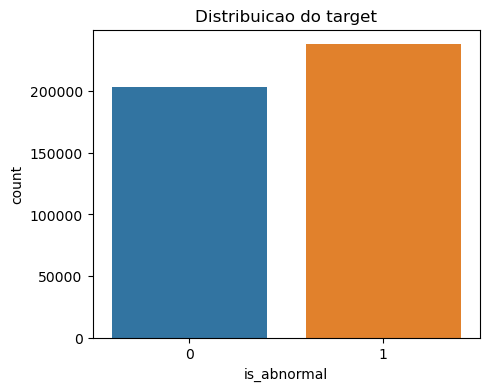

In [97]:
if "is_abnormal" not in df.columns:
    if "end_cause" not in df.columns:
        raise KeyError("Nao existe is_abnormal nem end_cause para definir o target.")
    df["is_abnormal"] = (df["end_cause"] != "Charging ends normally").astype(int)

target_summary = df["is_abnormal"].value_counts().sort_index().rename_axis("is_abnormal").to_frame("sessions")
target_summary["percentage"] = target_summary["sessions"] / len(df) * 100
display(target_summary)
print(f"Razao maioritaria/minoritaria: {target_summary['sessions'].max() / target_summary['sessions'].min():.2f}")
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="is_abnormal")
plt.title("Distribuicao do target")
plt.show()


## 2. Variáveis numéricas e relação com o target

Aqui comparamos as distribuições e os valores por classe, excluindo `userid` e `charging_post_id`, que são identificadores. Os outliers são observados, mas não são removidos.


is_abnormal                                    0          1
post_previous_sessions_1d      median  11.000000  10.000000
                               mean    10.684347  11.269720
post_previous_abnormal_1d      median   1.000000   1.000000
                               mean     1.442203   3.167987
post_previous_abnormal_rate_1d median   0.125000   0.166667
...                                          ...        ...
relative_humidity              mean    75.019400  75.039706
precipitation_mm               median   0.000000   0.000000
                               mean     3.486796   3.531116
electricity_price              median   0.901400   0.901400
                               mean     0.752737   0.751189

[64 rows x 2 columns]

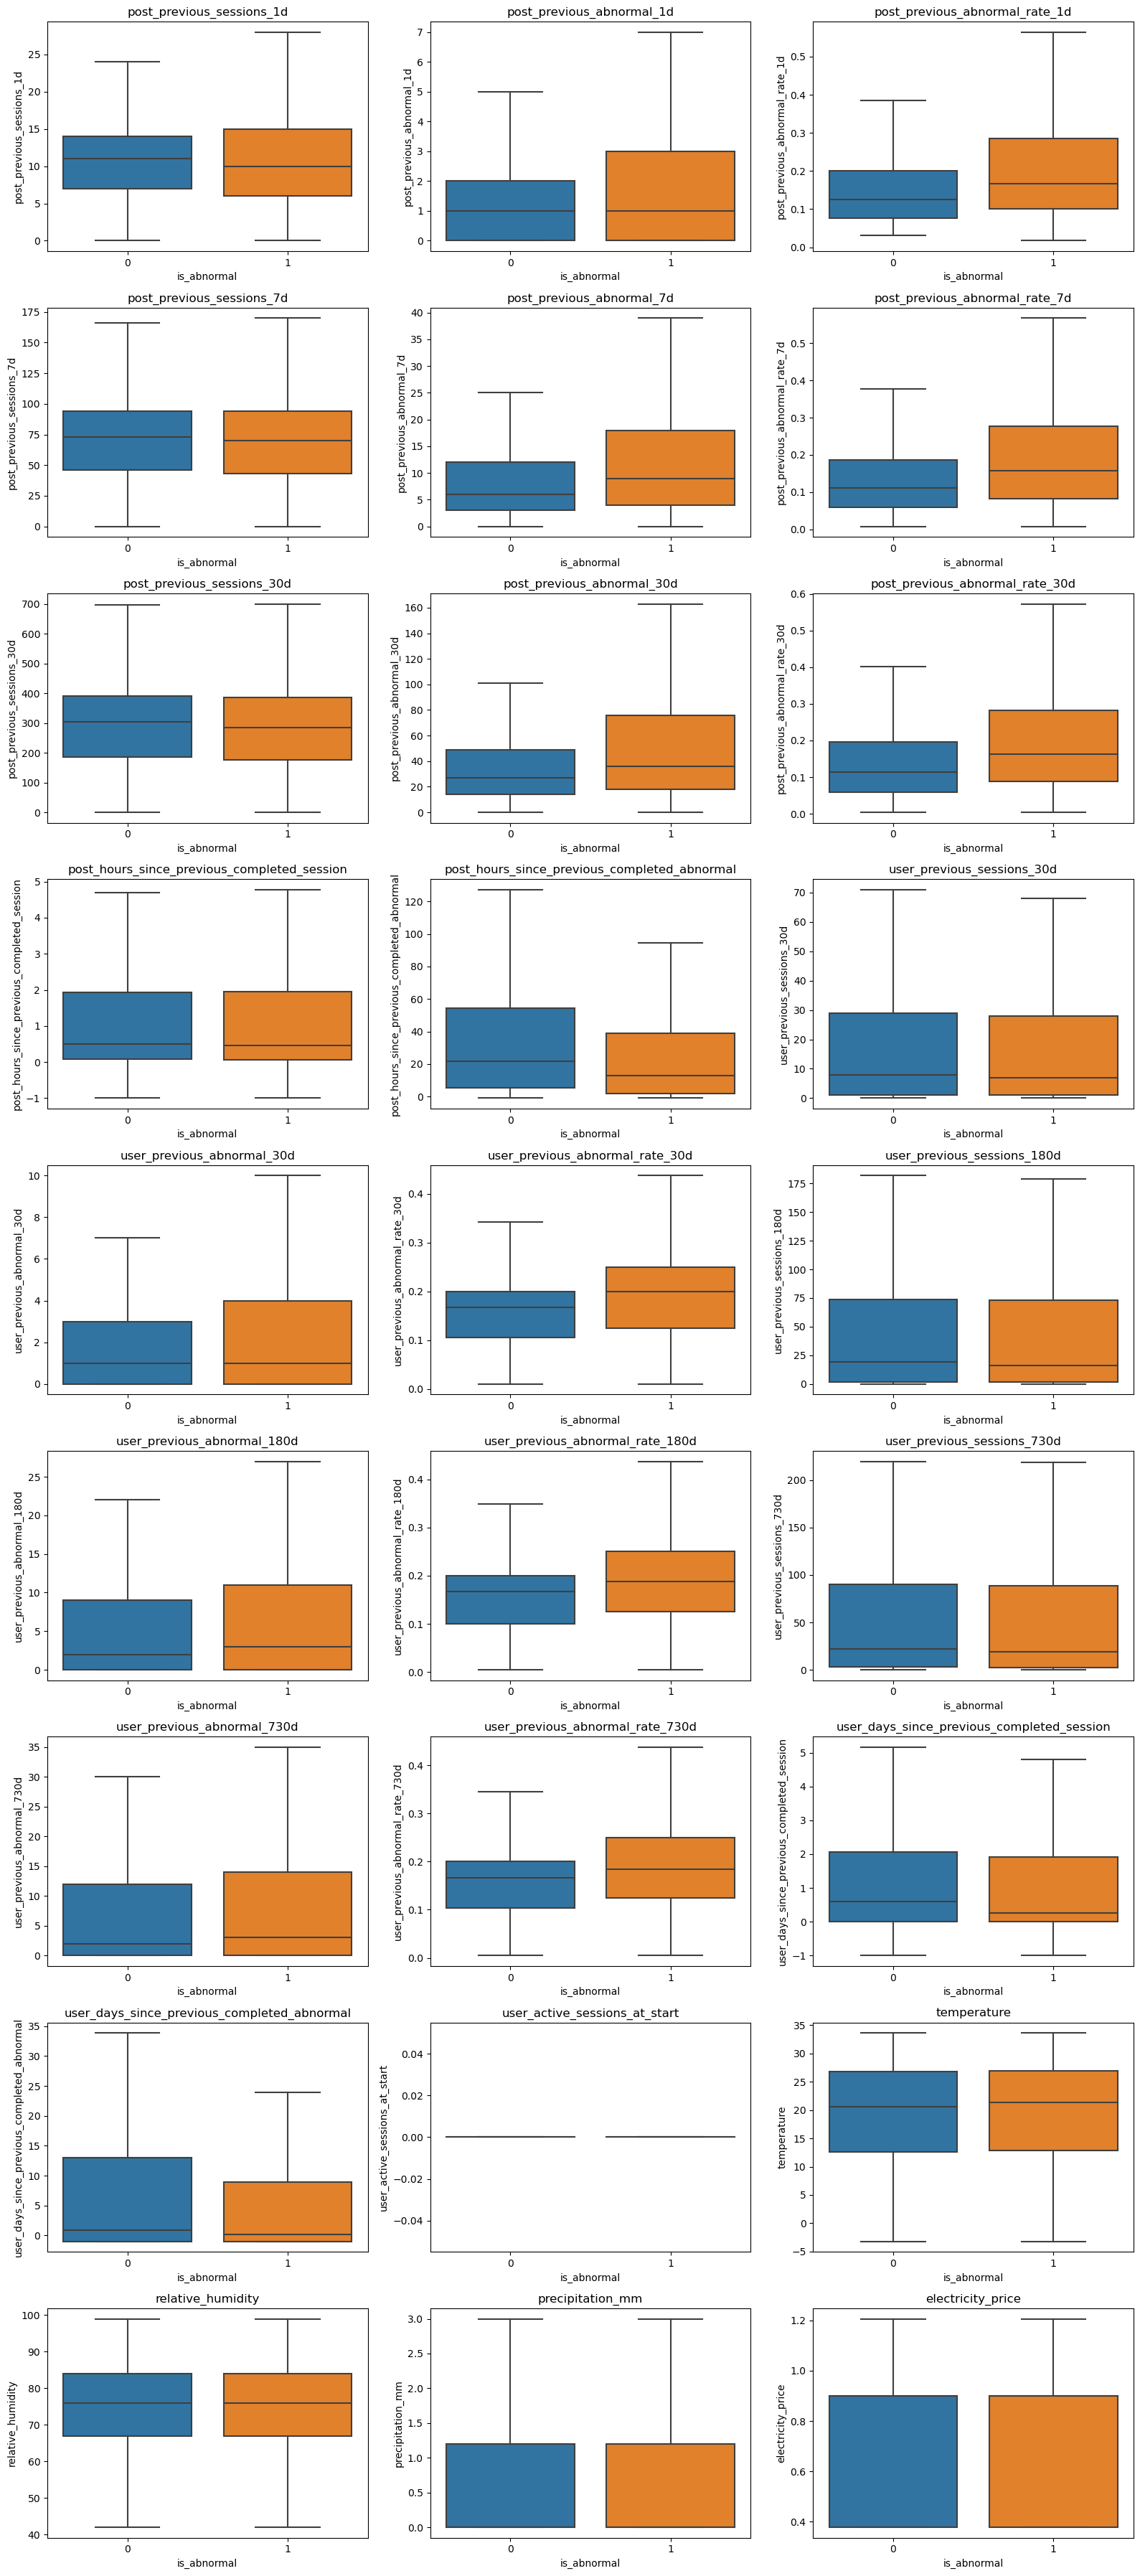

In [98]:
history_cols = [c for c in df.columns if c.startswith("post_") or c.startswith("user_")] + ["is_new_user"]
environment_cols = [c for c in ["temperature", "relative_humidity", "precipitation_mm", "electricity_price"] if c in df.columns]
eda_numeric = [c for c in history_cols + environment_cols if c in df.columns]
display(df.groupby("is_abnormal")[eda_numeric].agg(["median", "mean"]).T)
plot_cols = [c for c in eda_numeric if df[c].nunique(dropna=True) > 2]
fig, axes = plt.subplots(int(np.ceil(len(plot_cols) / 3)), 3, figsize=(16, 4 * int(np.ceil(len(plot_cols) / 3))))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x="is_abnormal", y=col, showfliers=False, ax=ax)
    ax.set_title(col)
for ax in axes[len(plot_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()


Diferenças nas medianas, médias ou dispersões indicam variáveis com comportamentos diferentes entre as classes e que poderão ser relevantes. As distribuições assimétricas devem ser consideradas mais tarde. Estas diferenças representam associações e não demonstram causalidade.


## 3. Outliers nas variáveis numéricas

Os outliers são observações muito afastadas do intervalo habitual de uma variável. Nesta fase, são identificados através da regra do intervalo interquartil (IQR), mas não são eliminados nem substituídos. A análise ajuda a perceber se algumas variáveis têm valores extremos ou distribuições muito assimétricas.

,variable,lower_bound,upper_bound,outlier_count,outlier_percentage
30,precipitation_mm,-1.800000,3.000000,84609,19.182365
22,user_days_since_previous_completed_session,-2.970243,4.952442,70996,16.096056
24,user_days_since_previous_completed_abnormal,-18.745660,28.576100,63859,14.477971
23,user_no_previous_completed_session,0.000000,0.000000,56647,12.842882
17,user_previous_abnormal_180d,-15.000000,25.000000,56638,12.840842
20,user_previous_abnormal_730d,-19.500000,32.500000,56481,12.805247
27,is_new_user,0.000000,0.000000,56116,12.722495
9,post_hours_since_previous_completed_session,-2.729028,4.736528,55524,12.588278
19,user_previous_sessions_730d,-126.000000,218.000000,52719,11.952335
16,user_previous_sessions_180d,-104.500000,179.500000,49725,11.273542


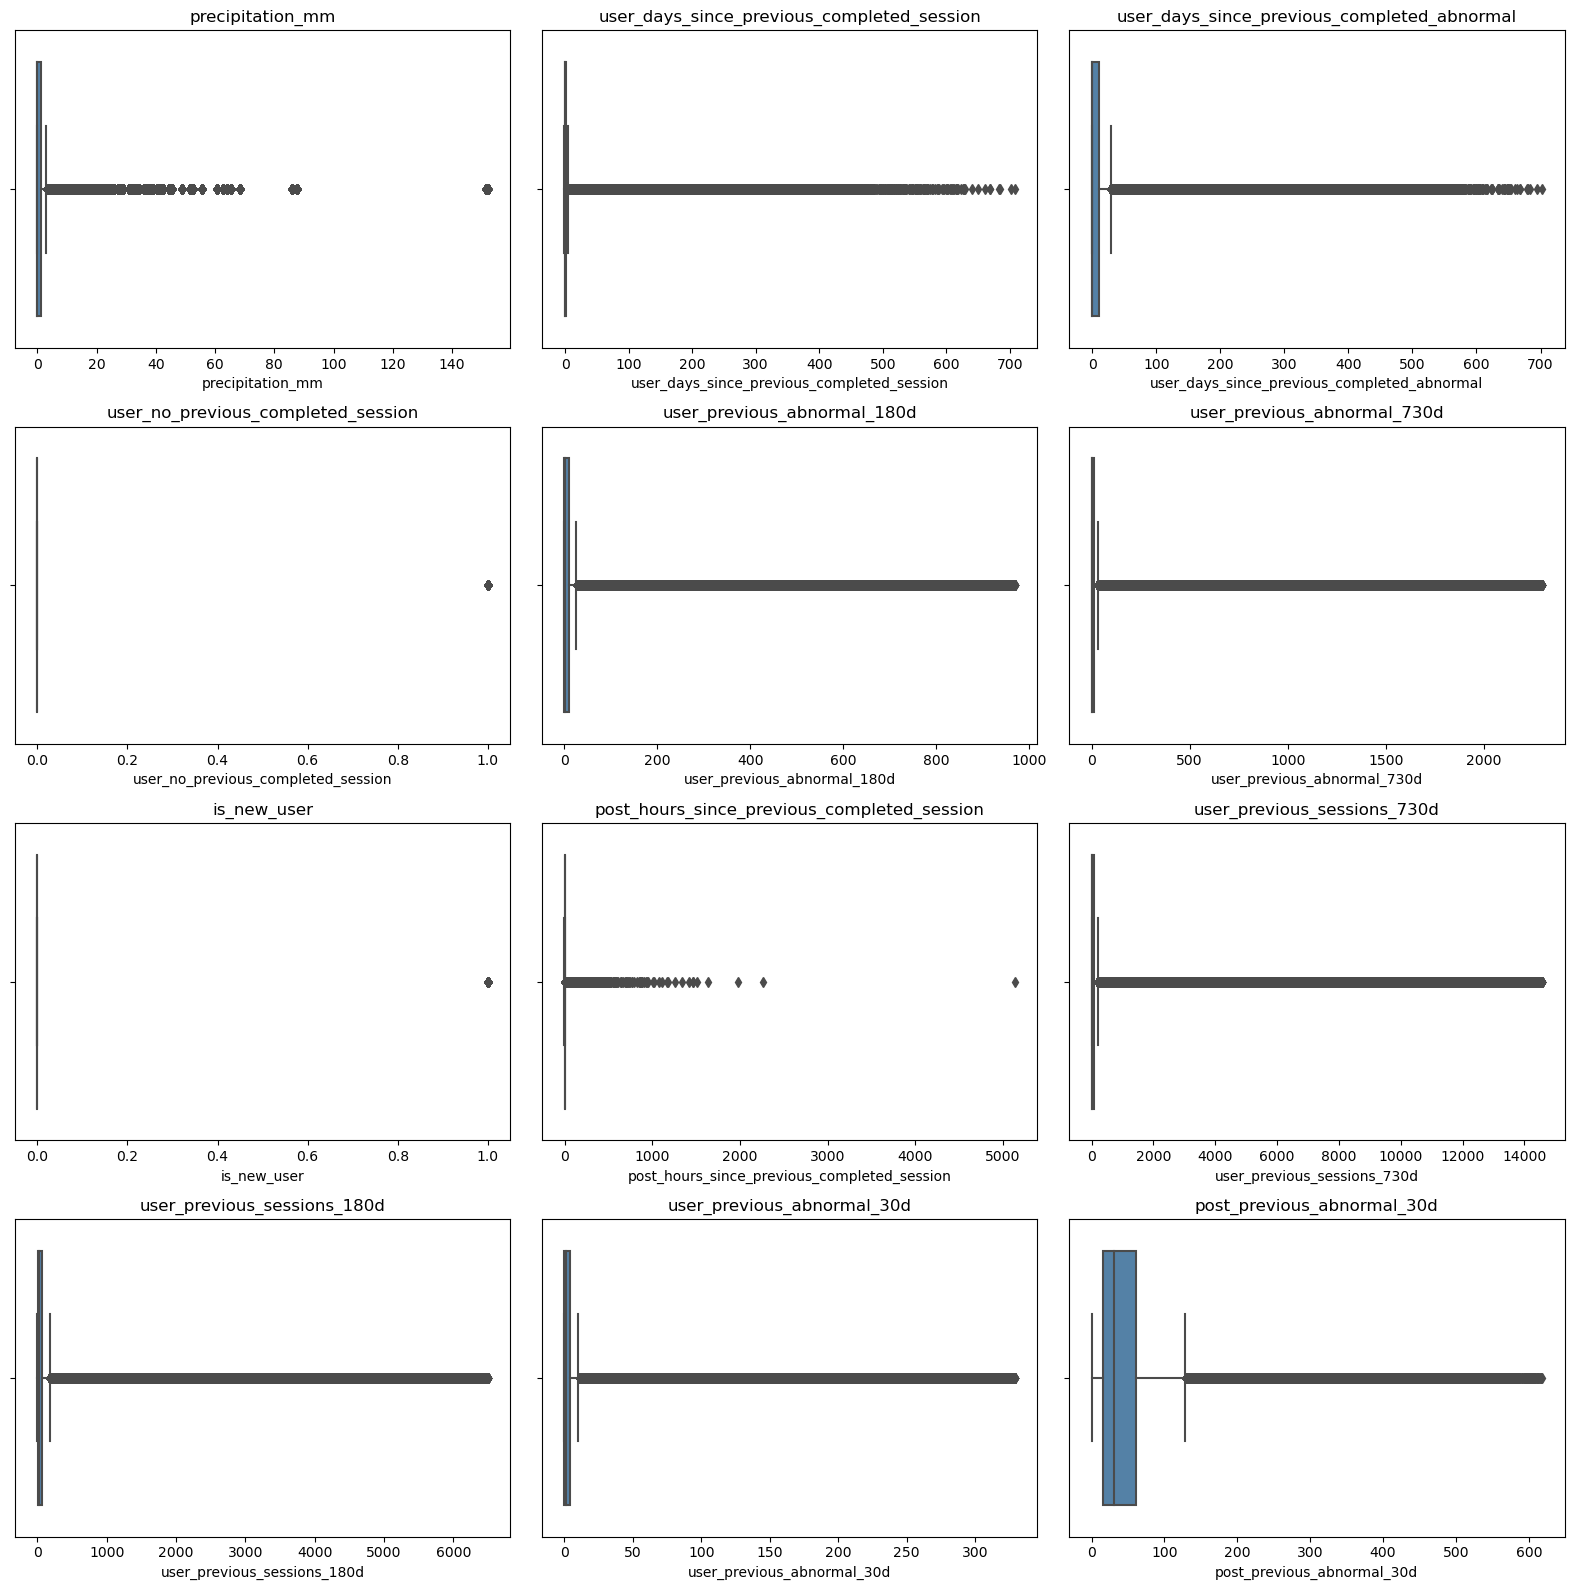

In [99]:
outlier_rows = []
for col in eda_numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_rows.append({
        "variable": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": mask.mean() * 100
    })

outlier_summary = (pd.DataFrame(outlier_rows)
                   .sort_values("outlier_percentage", ascending=False))
display(outlier_summary)

outlier_plot_cols = outlier_summary.head(12)["variable"].tolist()
fig, axes = plt.subplots(int(np.ceil(len(outlier_plot_cols) / 3)), 3,
                         figsize=(16, 4 * int(np.ceil(len(outlier_plot_cols) / 3))))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, outlier_plot_cols):
    sns.boxplot(x=df[col], ax=ax, color="steelblue")
    ax.set_title(col)
for ax in axes[len(outlier_plot_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

A tabela indica quais variáveis apresentam mais observações fora dos limites do IQR. Estes valores podem representar variabilidade real, distribuições assimétricas ou situações que devem ser investigadas. Não são considerados erros automaticamente e não são removidos nesta fase.

## 3. Variáveis categóricas

Nesta parte analisamos a relação de `location_information`, `district_name` e `tariff_period` com o target, mantendo as categorias raras e mostrando o número de sessões.


,sessions,abnormal_sessions,abnormal_rate
location_information,,,
Bus Station,60809,27327,44.939072
Park B,57294,24570,42.884072
Shopping Mall,56605,31812,56.199982
Expressway Service District C,50187,31624,63.012334
Government Agency,36551,17919,49.024650
Wholesale Market,34491,23609,68.449741
Technology Park,28867,13497,46.755811
Park A,27845,17628,63.307596
Tourist Attraction,23659,15340,64.837905


c:\Users\ritav\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


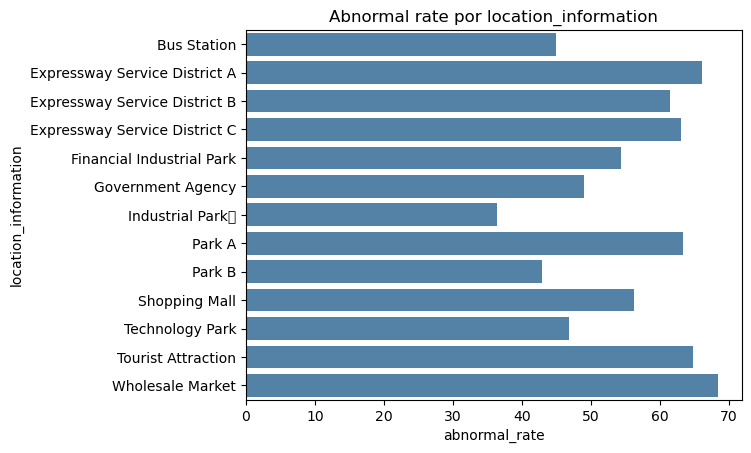

,sessions,abnormal_sessions,abnormal_rate
district_name,,,
Tongxiang,220923,108012,48.891243
Xiuzhou,148705,90729,61.012743
Nanhu,71449,39135,54.773335


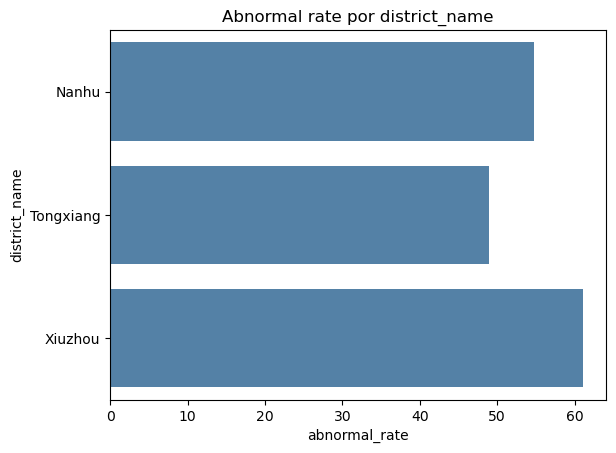

,sessions,abnormal_sessions,abnormal_rate
tariff_period,,,
peak_13_19,167118,92031,55.069472
off_peak_11_13,61760,35380,57.286269
peak_08_11,48977,26688,54.490883
off_peak_00_08,48633,24718,50.825571
sharp_19_21,48042,24692,51.396695
off_peak_22_24,43704,22622,51.761852
peak_21_22,22843,11745,51.416189


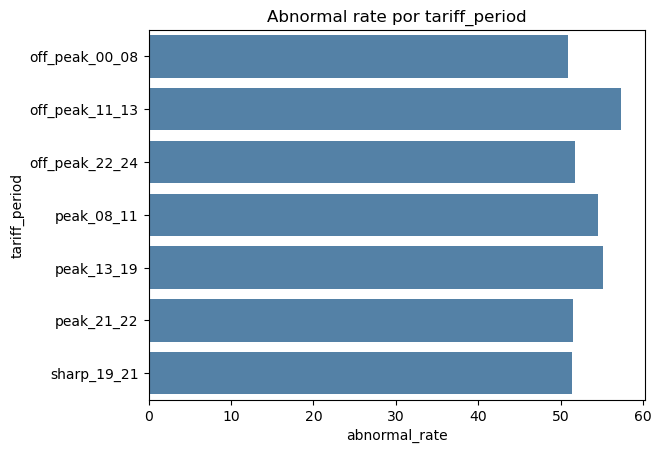

In [100]:
categorical_focus = [c for c in ["location_information", "district_name", "tariff_period"] if c in df.columns]
for col in categorical_focus:
    summary = df.groupby(col, dropna=False)["is_abnormal"].agg(sessions="size", abnormal_sessions="sum", abnormal_rate="mean")
    summary["abnormal_rate"] *= 100
    display(summary.sort_values("sessions", ascending=False))
    sns.barplot(data=summary.reset_index(), y=col, x="abnormal_rate", color="steelblue")
    plt.title(f"Abnormal rate por {col}")
    plt.show()


As categorias com abnormal rates diferentes apresentam uma associação observada com o target. As categorias com poucas sessões produzem estimativas menos estáveis. Não são eliminadas nem codificadas.


## 4. Relação entre as variáveis e o target

Comparamos os grupos de histórico do charging post e do utilizador. Estas variáveis representam informação disponível no início da sessão e podem revelar diferenças entre sessões normais e anormais.


In [101]:
feature_groups = {
    "Post history": [c for c in df.columns if c.startswith("post_")],
    "User history": [c for c in df.columns if c.startswith("user_")] + ["is_new_user"]
}
for group, cols in feature_groups.items():
    cols = [c for c in cols if c in df.columns]
    print(group)
    display(df.groupby("is_abnormal")[cols].mean().T)


Post history


is_abnormal,0,1
post_previous_sessions_1d,10.684347,11.269720
post_previous_abnormal_1d,1.442203,3.167987
post_previous_abnormal_rate_1d,0.152779,0.224281
post_previous_sessions_7d,70.818229,71.460589
post_previous_abnormal_7d,9.967397,17.235307
post_previous_abnormal_rate_7d,0.141545,0.218762
post_previous_sessions_30d,291.042323,286.169298
post_previous_abnormal_30d,43.112263,62.769426
post_previous_abnormal_rate_30d,0.148647,0.213710
post_hours_since_previous_completed_session,2.532074,2.870626


User history


is_abnormal,0,1
user_previous_sessions_30d,56.847870,54.753498
user_previous_abnormal_30d,8.398615,9.056811
user_previous_abnormal_rate_30d,0.173412,0.207784
user_previous_sessions_180d,195.606587,175.389829
user_previous_abnormal_180d,31.879838,30.055478
user_previous_abnormal_rate_180d,0.171023,0.205305
user_previous_sessions_730d,409.406942,305.122530
user_previous_abnormal_730d,65.120733,50.831185
user_previous_abnormal_rate_730d,0.171543,0.205632
user_days_since_previous_completed_session,6.739428,7.343377


Quando as médias ou medianas diferem entre as classes, o grupo apresenta comportamentos distintos e poderá ser relevante. Esta comparação não faz seleção de features nem permite afirmar causalidade.


## 5. District, Location e Charging Post

Analisamos a cardinalidade, as relações de pertença, o volume de sessões e a abnormal rate. Os charging posts com poucas observações exigem cautela.


In [102]:
for col in ["district_name", "location_information", "charging_post_id"]:
    print(col, df[col].nunique(dropna=False), "valores distintos")
display(df.groupby("district_name")["location_information"].nunique())
display(df.groupby("location_information")["charging_post_id"].nunique())
print("Post pertence a uma location:", df.groupby("charging_post_id")["location_information"].nunique().max() == 1)
print("Location pertence a um district:", df.groupby("location_information")["district_name"].nunique().max() == 1)
for col in ["district_name", "location_information", "charging_post_id"]:
    out = df.groupby(col)["is_abnormal"].agg(sessions="size", abnormal_rate="mean")
    out["abnormal_rate"] *= 100
    display(out.sort_values("sessions", ascending=False).head(20))


district_name 3 valores distintos
location_information 13 valores distintos
charging_post_id 92 valores distintos


district_name
Nanhu        3
Tongxiang    5
Xiuzhou      5
Name: location_information, dtype: int64

location_information
Bus Station                      8
Expressway Service District A    4
Expressway Service District B    4
Expressway Service District C    8
Financial Industrial Park        8
Government Agency                8
Industrial Park\t                8
Park A                           8
Park B                           8
Shopping Mall                    8
Technology Park                  4
Tourist Attraction               8
Wholesale Market                 8
Name: charging_post_id, dtype: int64

Post pertence a uma location: True
Location pertence a um district: True


,sessions,abnormal_rate
district_name,,
Tongxiang,220923,48.891243
Xiuzhou,148705,61.012743
Nanhu,71449,54.773335


,sessions,abnormal_rate
location_information,,
Bus Station,60809,44.939072
Park B,57294,42.884072
Shopping Mall,56605,56.199982
Expressway Service District C,50187,63.012334
Government Agency,36551,49.024650
Wholesale Market,34491,68.449741
Technology Park,28867,46.755811
Park A,27845,63.307596
Tourist Attraction,23659,64.837905


,sessions,abnormal_rate
charging_post_id,,
77,8728,62.110449
46,8097,38.285785
54,7990,56.933667
59,7858,43.649784
79,7854,70.881080
52,7842,39.747513
53,7659,47.068808
56,7626,43.902439
21,7619,60.191626


A consistência das pertenças mostra se existe uma hierarquia estável. Os volumes e as abnormal rates descrevem diferenças de utilização, mas não provam que uma location ou um charging post cause anomalias.


## 6. Preparação temporal
Criamos variáveis auxiliares para a EDA: ano, mês, semana, dia, dia da semana e hora. 


In [103]:
for col in ["order_creation_time", "start_time"]:
    if not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], errors="coerce")
session_time = df["start_time"].fillna(df["order_creation_time"])
df["eda_year"] = session_time.dt.year
df["eda_month"] = session_time.dt.to_period("M").astype(str)
df["eda_week"] = session_time.dt.to_period("W").astype(str)
df["eda_day"] = session_time.dt.date
df["eda_day_of_week"] = session_time.dt.day_name()
df["eda_hour"] = session_time.dt.hour
print(df[["order_creation_time", "start_time", "eda_month", "eda_day_of_week", "eda_hour"]].head())


  order_creation_time          start_time eda_month eda_day_of_week  eda_hour
0 2019-12-31 21:26:58 2019-12-31 21:27:03   2019-12         Tuesday        21
1 2019-12-31 21:50:58 2019-12-31 21:50:56   2019-12         Tuesday        21
2 2019-12-31 22:19:34 2019-12-31 22:12:46   2019-12         Tuesday        22
3 2019-12-31 22:37:24 2019-12-31 22:38:55   2019-12         Tuesday        22
4 2019-12-31 23:32:28 2019-12-31 23:06:44   2019-12         Tuesday        23


## 7. Volume de sessões ao longo do tempo

A contagem por mês e por semana identifica períodos de maior ou menor atividade, sazonalidade aparente ou alterações abruptas, sem inventar causas.


,sessions
eda_month,
2019-12,17
2020-01,6217
2020-02,1391
2020-03,6392
2020-04,11136
2020-05,15033
2020-06,17513
2020-07,22032
2020-08,25562


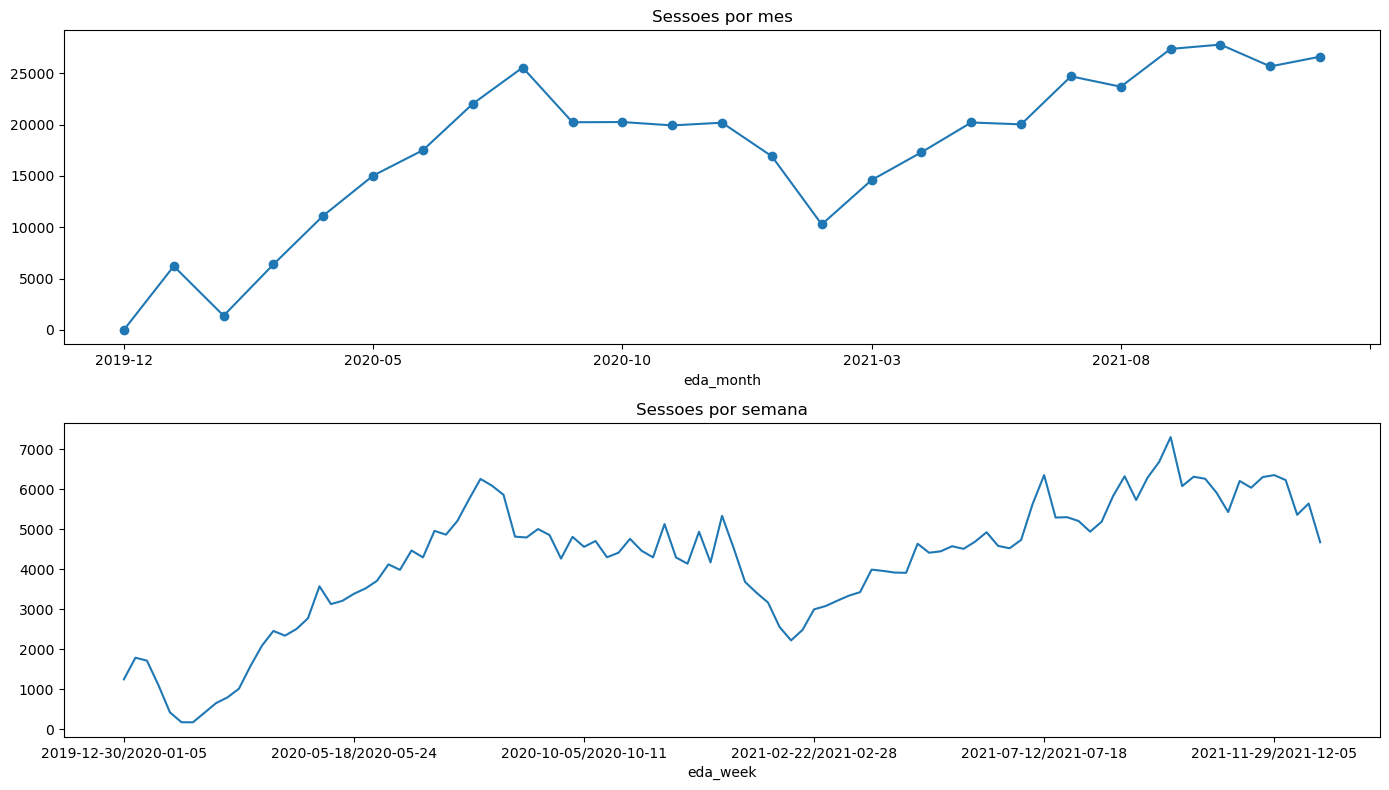

In [104]:
monthly_volume = df.groupby("eda_month").size().rename("sessions")
weekly_volume = df.groupby("eda_week").size().rename("sessions")
display(monthly_volume.to_frame())
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
monthly_volume.plot(ax=axes[0], marker="o", title="Sessoes por mes")
weekly_volume.plot(ax=axes[1], title="Sessoes por semana")
plt.tight_layout()
plt.show()


Os picos e vales representam alterações reais no volume observado. Os períodos com poucas sessões devem ser interpretados com cuidado e a variação não permite inferir a sua causa.


## 8. Abnormal rate ao longo do tempo

Calculamos mensalmente `abnormal_rate = sessões anormais / sessões totais`, mostrando também o volume total.


,sessions,abnormal_sessions,abnormal_rate
eda_month,,,
2019-12,17,9,52.941176
2020-01,6217,3428,55.139135
2020-02,1391,799,57.440690
2020-03,6392,3644,57.008761
2020-04,11136,6126,55.010776
2020-05,15033,7943,52.837092
2020-06,17513,9554,54.553760
2020-07,22032,12118,55.001816
2020-08,25562,14780,57.820202


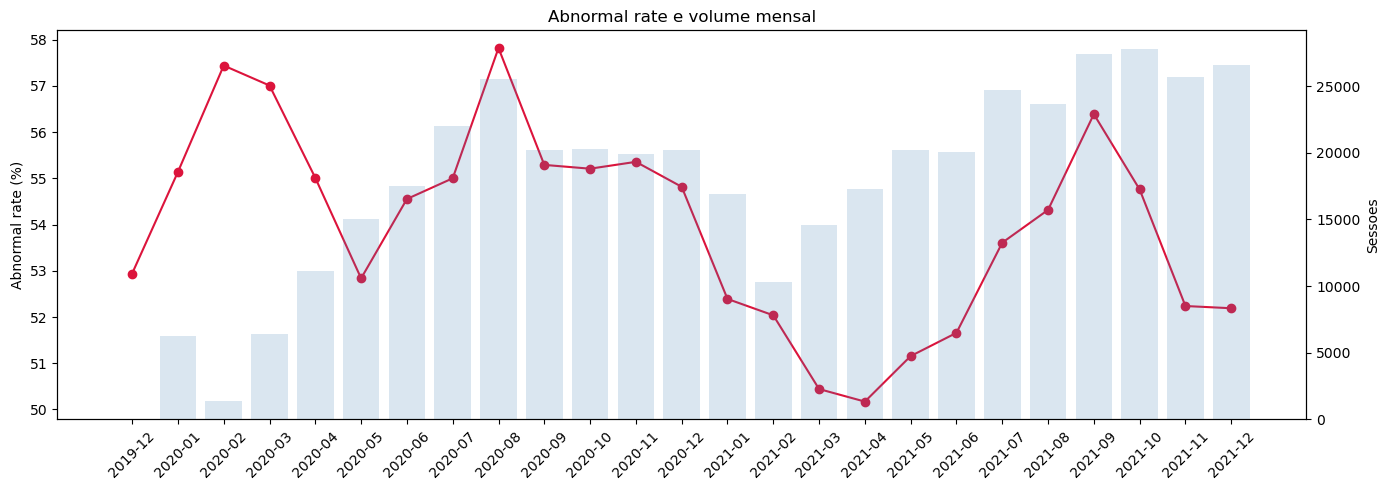

In [105]:
monthly_rate = df.groupby("eda_month")["is_abnormal"].agg(sessions="size", abnormal_sessions="sum", abnormal_rate="mean")
monthly_rate["abnormal_rate"] *= 100
display(monthly_rate)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly_rate.index, monthly_rate["abnormal_rate"], marker="o", color="crimson")
ax1.set_ylabel("Abnormal rate (%)")
ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.bar(monthly_rate.index, monthly_rate["sessions"], alpha=.2, color="steelblue")
ax2.set_ylabel("Sessoes")
plt.title("Abnormal rate e volume mensal")
plt.tight_layout()
plt.show()


A estabilidade ou variação da abnormal rate deve ser avaliada juntamente com o volume. Pequenas diferenças em meses com poucas sessões não são evidência suficiente de temporal drift.


## 9. Análise por hora, dia da semana e mês

Agregamos as sessões, as sessões anormais e a abnormal rate por hora, dia da semana e mês. A ordem dos dias é fixada de Monday a Sunday.


,sessions,abnormal_sessions,abnormal_rate
eda_hour,,,
0,11381,5544,48.712767
1,7012,3224,45.978323
2,5101,2316,45.402862
3,4548,2086,45.866315
4,3969,1955,49.256740
5,3876,2334,60.216718
6,5670,3372,59.470899
7,7076,3887,54.932165
8,9746,5011,51.415966


,sessions,abnormal_sessions,abnormal_rate
eda_day_of_week,,,
Monday,62064,33139,53.394883
Tuesday,61465,32896,53.519889
Wednesday,62093,33329,53.675938
Thursday,63220,34402,54.416324
Friday,65562,35704,54.458375
Saturday,64463,34660,53.767277
Sunday,62210,33746,54.245298


,sessions,abnormal_sessions,abnormal_rate
eda_month,,,
2019-12,17,9,52.941176
2020-01,6217,3428,55.139135
2020-02,1391,799,57.440690
2020-03,6392,3644,57.008761
2020-04,11136,6126,55.010776
2020-05,15033,7943,52.837092
2020-06,17513,9554,54.553760
2020-07,22032,12118,55.001816
2020-08,25562,14780,57.820202


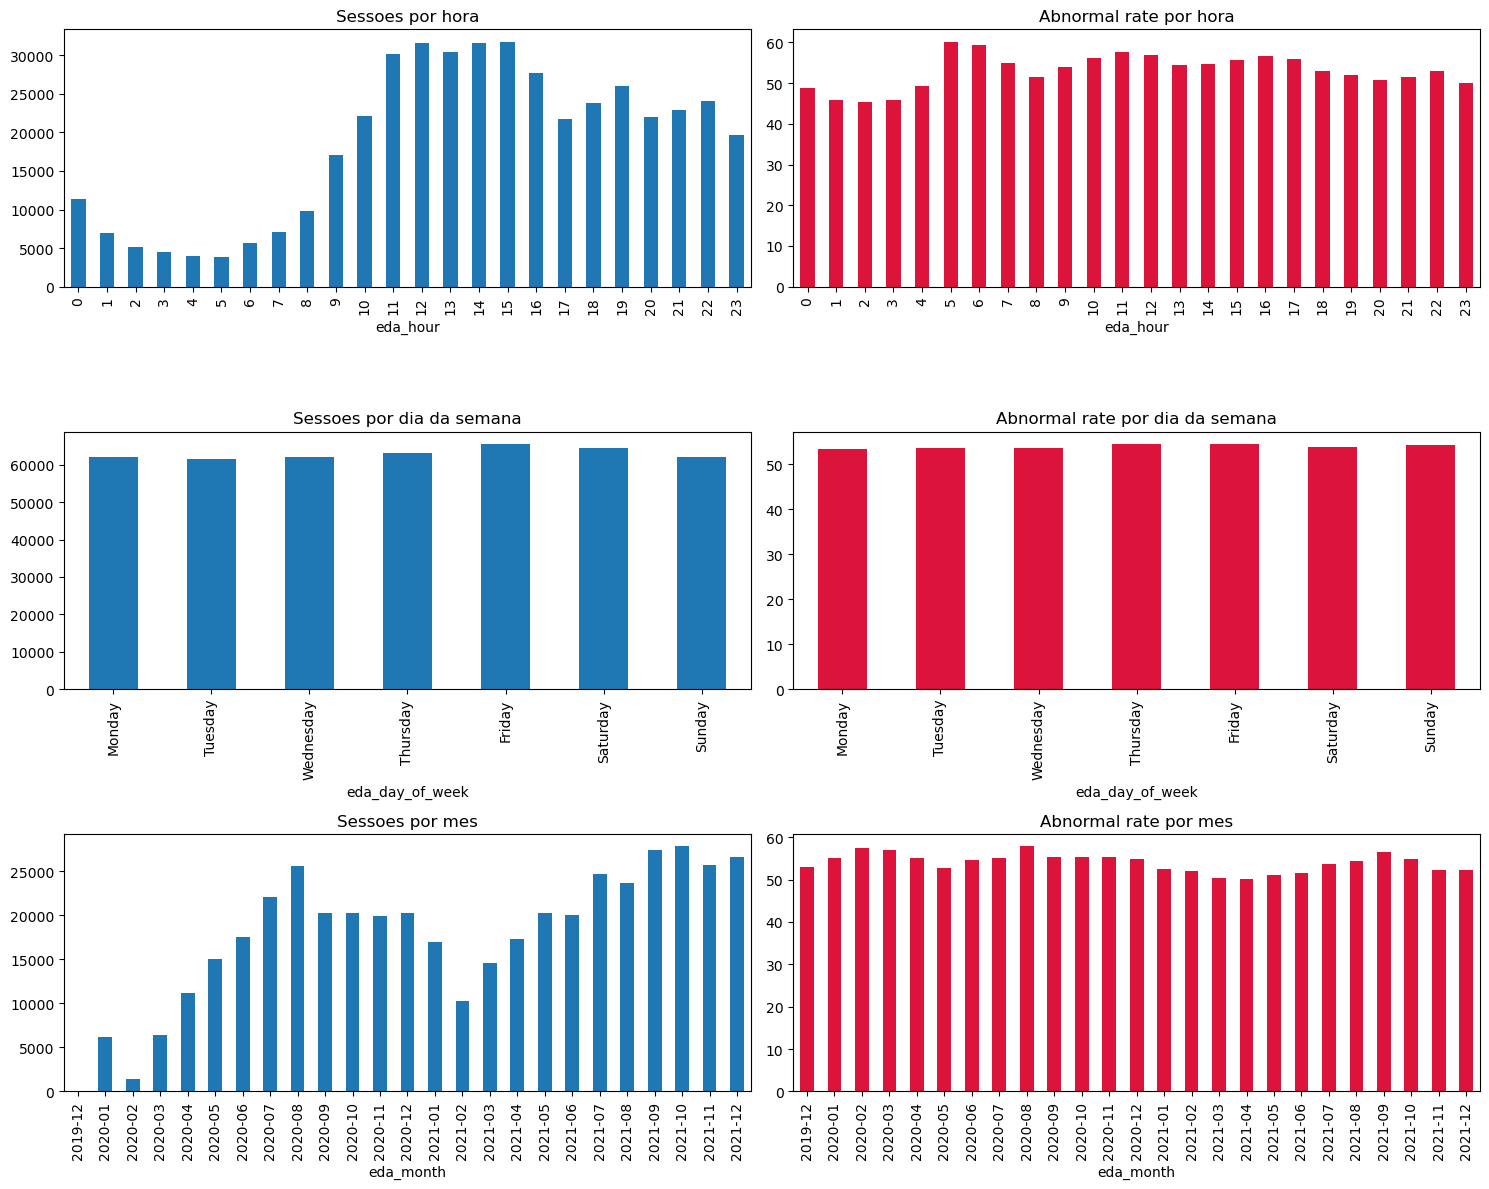

In [106]:
def temporal_summary(column):
    out = df.groupby(column)["is_abnormal"].agg(sessions="size", abnormal_sessions="sum", abnormal_rate="mean")
    out["abnormal_rate"] *= 100
    return out
hour_summary = temporal_summary("eda_hour")
day_summary = temporal_summary("eda_day_of_week").reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
month_summary = temporal_summary("eda_month")
display(hour_summary)
display(day_summary)
display(month_summary)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
for row, summary, title in [(0, hour_summary, "hora"), (1, day_summary, "dia da semana"), (2, month_summary, "mes")]:
    summary["sessions"].plot(kind="bar", ax=axes[row, 0], title=f"Sessoes por {title}")
    summary["abnormal_rate"].plot(kind="bar", ax=axes[row, 1], color="crimson", title=f"Abnormal rate por {title}")
plt.tight_layout()
plt.show()


Os gráficos mostram os períodos com maior volume e as diferenças de abnormal rate. Qualquer padrão deve ser suportado pelo número de sessões; diferenças observacionais não demonstram causalidade.


## 10. Atividade dos utilizadores

Analisamos os utilizadores distintos por mês, as sessões por utilizador, `is_new_user` e `user_active_sessions_at_start`, para perceber se a população e a intensidade de utilização mudam.


,distinct_users
eda_month,
2019-12,16
2020-01,1963
2020-02,516
2020-03,1797
2020-04,2622
2020-05,3153
2020-06,3185
2020-07,3704
2020-08,4733


,sessions
count,56115.000000
mean,7.860233
std,74.159350
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,14584.000000


,sessions,abnormal_rate
is_new_user,,
0,384961,0.539966
1,56116,0.534785


,sessions,abnormal_rate
user_active_sessions_at_start,,
0,420500,0.538419
1,11718,0.578170
2,3799,0.519347
3,2026,0.511846
4,1153,0.553339
5,728,0.557692
6,448,0.529018
7,304,0.562500
8,197,0.553299


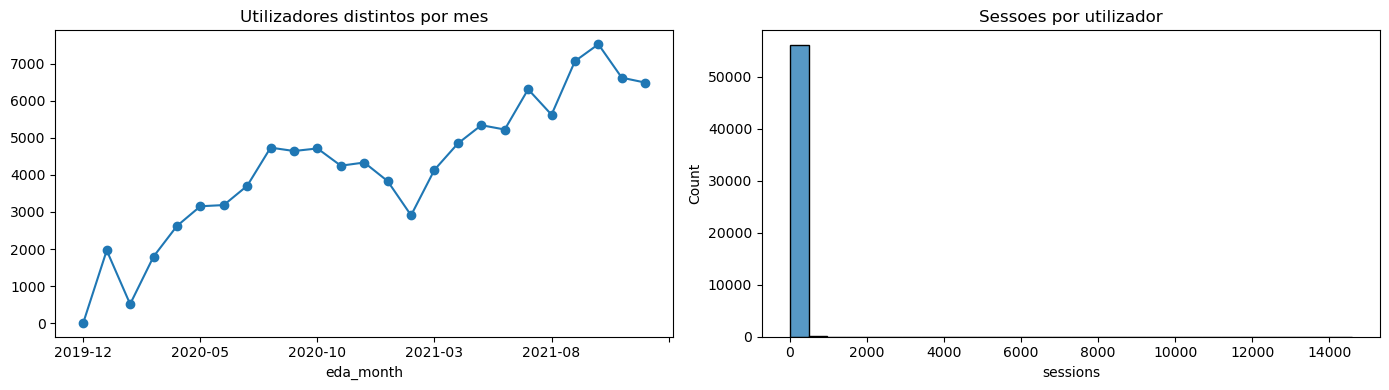

In [107]:
sessions_per_user = df.groupby("userid").size().rename("sessions")
users_by_month = df.groupby("eda_month")["userid"].nunique().rename("distinct_users")
display(users_by_month.to_frame())
display(sessions_per_user.describe().to_frame())
for col in ["is_new_user", "user_active_sessions_at_start"]:
    display(df.groupby(col)["is_abnormal"].agg(sessions="size", abnormal_rate="mean"))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
users_by_month.plot(ax=axes[0], marker="o", title="Utilizadores distintos por mes")
sns.histplot(sessions_per_user, bins=30, ax=axes[1])
axes[1].set_title("Sessoes por utilizador")
plt.tight_layout()
plt.show()


A evolução dos utilizadores distintos indica se a população observada muda. A distribuição de sessões mostra se a atividade está concentrada em poucos utilizadores. As relações com o target são descritivas.


## 11. Atividade dos charging posts

Analisamos os charging posts ativos por mês, as sessões por post e a abnormal rate por post. Os posts com poucas observações são mantidos, mas não sustentam conclusões fortes.


,active_posts
eda_month,
2019-12,17
2020-01,92
2020-02,83
2020-03,92
2020-04,92
2020-05,92
2020-06,91
2020-07,92
2020-08,92


,sessions
count,92.000000
mean,4794.315217
std,2157.846107
min,797.000000
25%,2957.500000
50%,4368.000000
75%,7064.750000
max,8728.000000


,sessions,abnormal_rate
charging_post_id,,
77,8728,62.110449
46,8097,38.285785
54,7990,56.933667
59,7858,43.649784
79,7854,70.881080
52,7842,39.747513
53,7659,47.068808
56,7626,43.902439
21,7619,60.191626


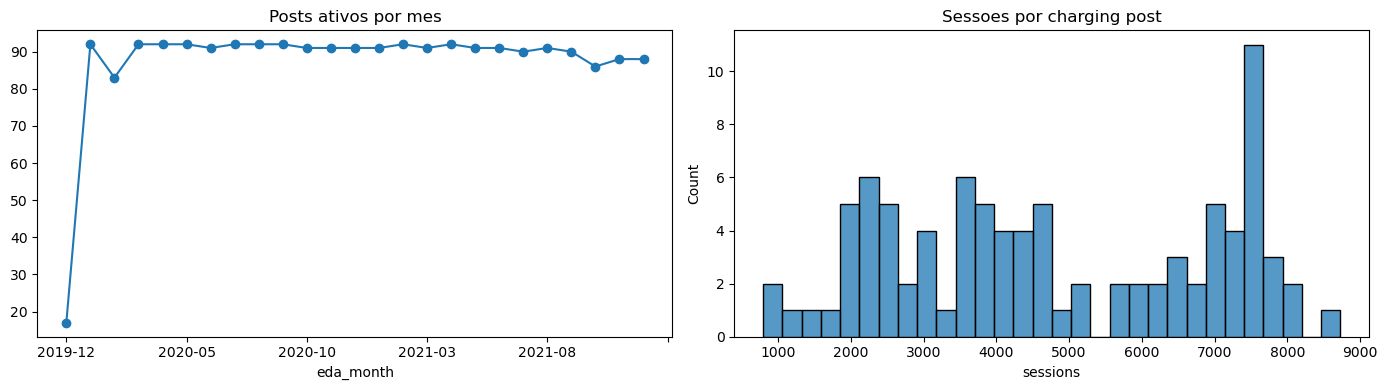

In [108]:
posts_by_month = df.groupby("eda_month")["charging_post_id"].nunique().rename("active_posts")
sessions_per_post = df.groupby("charging_post_id").size().rename("sessions")
post_summary = df.groupby("charging_post_id")["is_abnormal"].agg(sessions="size", abnormal_rate="mean")
post_summary["abnormal_rate"] *= 100
display(posts_by_month.to_frame())
display(sessions_per_post.describe().to_frame())
display(post_summary.sort_values("sessions", ascending=False).head(20))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
posts_by_month.plot(ax=axes[0], marker="o", title="Posts ativos por mes")
sns.histplot(sessions_per_post, bins=30, ax=axes[1])
axes[1].set_title("Sessoes por charging post")
plt.tight_layout()
plt.show()


A evolução dos charging posts ativos e a distribuição das sessões descrevem a utilização da infraestrutura. Uma abnormal rate elevada num post com poucas observações é incerta e não demonstra um efeito causal.


## 12. Análise de correlação

Calculamos uma matriz apenas para as variáveis numéricas de histórico e ambientais, excluindo identificadores e variáveis posteriores à sessão. Correlação não significa causalidade nem determina a remoção de variáveis.


,post_previous_sessions_1d,post_previous_abnormal_1d,post_previous_abnormal_rate_1d,post_previous_sessions_7d,post_previous_abnormal_7d,post_previous_abnormal_rate_7d,post_previous_sessions_30d,post_previous_abnormal_30d,post_previous_abnormal_rate_30d,post_hours_since_previous_completed_session,...,user_no_previous_completed_session,user_days_since_previous_completed_abnormal,user_no_previous_completed_abnormal,user_active_sessions_at_start,is_new_user,temperature,relative_humidity,precipitation_mm,electricity_price,is_abnormal
post_previous_sessions_1d,1.000000,0.646801,0.301353,0.788516,0.497633,0.185250,0.696470,0.445817,0.119599,-0.159744,...,-0.039252,-0.012372,-0.065078,-0.006109,-0.039164,0.114629,-0.064283,-0.003122,-0.007440,0.044685
post_previous_abnormal_1d,0.646801,1.000000,0.848843,0.419314,0.752062,0.631096,0.287843,0.583567,0.487521,-0.047800,...,0.024038,-0.048758,-0.030661,-0.011349,0.023319,0.094627,-0.015878,0.007691,-0.000473,0.179299
post_previous_abnormal_rate_1d,0.301353,0.848843,1.000000,0.147684,0.681995,0.777721,0.037576,0.527585,0.624617,0.004240,...,0.054219,-0.068111,-0.015262,-0.012689,0.053083,0.053442,0.006642,0.012918,-0.004274,0.225159
post_previous_sessions_7d,0.788516,0.419314,0.147684,1.000000,0.575638,0.156205,0.898664,0.522467,0.080130,-0.162563,...,-0.033724,-0.002121,-0.057242,-0.008538,-0.033535,0.132995,-0.056147,-0.000098,-0.002100,0.009136
post_previous_abnormal_7d,0.497633,0.752062,0.681995,0.575638,1.000000,0.806959,0.413540,0.801776,0.635334,-0.048083,...,0.056396,-0.051151,-0.001159,-0.013599,0.055455,0.118979,-0.006045,0.014954,0.001565,0.170167
post_previous_abnormal_rate_7d,0.185250,0.631096,0.777721,0.156205,0.806959,1.000000,0.037740,0.650322,0.824643,0.016531,...,0.087736,-0.073908,0.015945,-0.014088,0.086425,0.053684,0.016541,0.013985,-0.005387,0.225458
post_previous_sessions_30d,0.696470,0.287843,0.037576,0.898664,0.413540,0.037740,1.000000,0.536907,0.036775,-0.156609,...,-0.038670,0.009307,-0.056754,-0.014269,-0.038303,0.105865,-0.058821,0.003355,-0.002020,-0.017521
post_previous_abnormal_30d,0.445817,0.583567,0.527585,0.522467,0.801776,0.650322,0.536907,1.000000,0.767154,-0.052113,...,0.080919,-0.054225,0.021588,-0.011676,0.079992,0.127122,0.001291,0.019651,0.000822,0.146250
post_previous_abnormal_rate_30d,0.119599,0.487521,0.624617,0.080130,0.635334,0.824643,0.036775,0.767154,1.000000,0.028360,...,0.113342,-0.080863,0.040485,-0.009858,0.111835,0.054569,0.026432,0.013766,-0.004675,0.205943
post_hours_since_previous_completed_session,-0.159744,-0.047800,0.004240,-0.162563,-0.048083,0.016531,-0.156609,-0.052113,0.028360,1.000000,...,0.030088,-0.000444,0.024000,-0.002139,0.029866,-0.040252,0.005343,-0.005362,-0.013007,0.010394


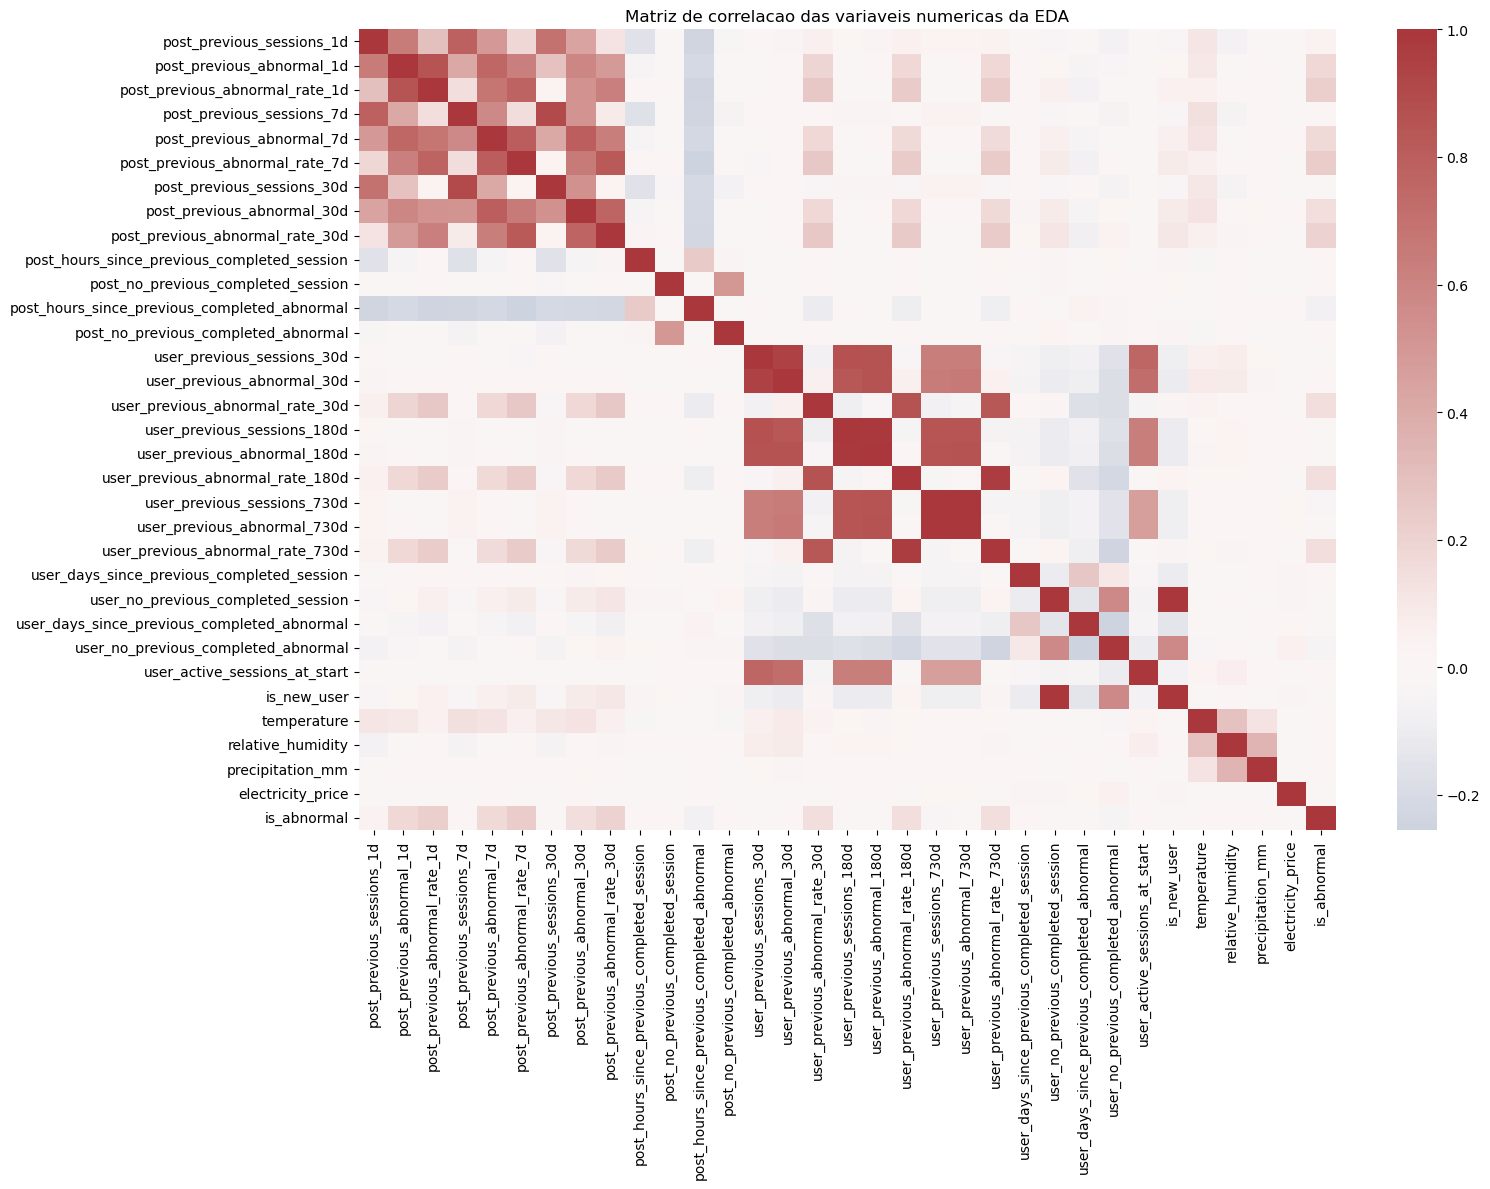

In [109]:
corr_cols = [c for c in eda_numeric + ["is_abnormal"] if c in df.columns]
corr_matrix = df[corr_cols].corr()
display(corr_matrix)
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="vlag", center=0)
plt.title("Matriz de correlacao das variaveis numericas da EDA")
plt.tight_layout()
plt.show()


A matriz permite identificar vari?veis relacionadas e poss?veis redund?ncias, mas n?o estabelece causalidade. A decis?o final sobre as vari?veis pertence ? fase de modela??o.


## 13. Temporal drift

Comparamos mensalmente o volume, a abnormal rate, as variáveis numéricas, os utilizadores, os charging posts e as categorias principais. O objetivo é decidir se o comportamento parece estável, se existem alterações temporais ou se a evidência é insuficiente.


In [110]:
drift_numeric = [c for c in ["temperature", "relative_humidity", "precipitation_mm", "electricity_price", "user_active_sessions_at_start"] if c in df.columns]
monthly_numeric = df.groupby("eda_month")[drift_numeric].median()
drift_table = monthly_rate[["sessions", "abnormal_rate"]].copy()
drift_table["distinct_users"] = users_by_month
drift_table["active_posts"] = posts_by_month
display(monthly_numeric)
display(drift_table)


,temperature,relative_humidity,precipitation_mm,electricity_price,user_active_sessions_at_start
eda_month,,,,,
2019-12,3.9,61.0,0.1,0.3784,0.0
2020-01,6.1,87.0,0.3,0.9014,0.0
2020-02,10.1,76.0,0.0,0.9014,0.0
2020-03,12.6,76.0,0.1,0.9014,0.0
2020-04,16.0,66.0,0.0,0.9014,0.0
2020-05,23.2,79.0,0.0,0.9014,0.0
2020-06,26.1,90.0,2.1,0.9014,0.0
2020-07,26.6,89.0,0.9,0.9014,0.0
2020-08,31.2,72.0,0.0,0.9014,0.0


,sessions,abnormal_rate,distinct_users,active_posts
eda_month,,,,
2019-12,17,52.941176,16,17
2020-01,6217,55.139135,1963,92
2020-02,1391,57.440690,516,83
2020-03,6392,57.008761,1797,92
2020-04,11136,55.010776,2622,92
2020-05,15033,52.837092,3153,92
2020-06,17513,54.553760,3185,91
2020-07,22032,55.001816,3704,92
2020-08,25562,57.820202,4733,92
